# A3 – Inteligência Artificial
## Comitê de Classificadores: Previsão de Churn em Telecomunicações

**Disciplina:** Inteligência Artificial  
**Universidade:** Universidade São Judas Tadeu  
**Prazo de entrega:** 09/06/2026

---

### Integrantes do Grupo
- César Melo Ribeiro
- Julia Leite Venancio
- Kaue Lucas da Silva
- Vinicius Iandoli Diogo

---

## 1. Introdução

O **churn** (cancelamento de clientes) é um dos problemas mais críticos para empresas de telecomunicações. Perder um cliente custa, em média, 5 a 25 vezes mais do que reter um já existente. Prever quais clientes têm maior probabilidade de cancelar permite que a empresa adote ações preventivas — como ofertas personalizadas ou melhorias no serviço — antes que a perda ocorra.

Este projeto aplica técnicas de **aprendizado de máquina supervisionado** para construir um **comitê de classificadores (ensemble)**, combinando os algoritmos KNN, Naive Bayes, Árvore de Decisão e SVM. A abordagem em comitê tem como objetivo superar o desempenho individual de cada modelo, aproveitando a diversidade entre eles.

**Pipeline do projeto:**
1. Escolha e justificativa da base de dados
2. Definição do problema e da variável target
3. Pré-processamento e análise exploratória (EDA)
4. Treinamento e avaliação individual dos classificadores
5. Construção do comitê (ensemble) por votação majoritária
6. Comparação de resultados e conclusões

## 2. Importação de Bibliotecas

In [1]:
# ============================================================
# IMPORTAÇÃO DE BIBLIOTECAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Pré-processamento
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Classificadores individuais
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier

# Comitê de classificadores
from sklearn.ensemble import VotingClassifier

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# Configuração visual
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_STATE = 42
print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


## 3. Base de Dados

### 3.1 Escolha e Justificativa

**Base:** *Telecom Churn Dataset* — disponível no Kaggle (dataset de operadora de telecomunicações indiana).

**Justificativa da escolha:**
- É um problema real e relevante de classificação binária
- Possui volume expressivo (~100.000 registros) e alta dimensionalidade (226 colunas)
- Permite aplicar todas as etapas do pipeline: pré-processamento rico, feature engineering e avaliação comparativa de modelos
- O desbalanceamento de classes (~5% de churn) é comum em problemas reais e exige atenção nas métricas

**Estrutura:** Dados mensais de uso de telefonia (minutos de voz, dados móveis, recargas) referentes aos meses de junho a setembro de 2014, identificados pelos sufixos `_6`, `_7`, `_8`, `_9`.

In [2]:
# ============================================================
# CARREGAMENTO DO DATASET
# ============================================================
# Ajuste o caminho conforme necessário
df = pd.read_csv('telecom_churn_data.csv')

print(f'Shape original: {df.shape}')
print(f'\nPrimeiras linhas:')
df.head(3)

FileNotFoundError: [Errno 2] No such file or directory: 'telecom_churn_data.csv'

## 4. Definição do Problema

### 4.1 Variável Target (y)

A base não possui uma coluna `churn` explícita. Seguindo a abordagem padrão para este dataset (metodologia de previsão baseada em comportamento temporal):

- **Meses 6 e 7 (junho/julho):** período de referência — comportamento "normal" do cliente
- **Mês 8 (agosto):** período de monitoramento — identificação de mudanças no comportamento
- **Mês 9 (setembro):** período de ação — **churn** = cliente que tinha uso no mês 8 mas ficou com ARPU zero no mês 9

**Definição formal:**
> `churn = 1` se `arpu_9 == 0` **e** `arpu_8 > 0` (cliente ativo que cancelou)  
> `churn = 0` caso contrário (cliente retido)

### 4.2 Variáveis Independentes (X)

Utilizamos as features dos **meses 6, 7 e 8** (excluindo dados do mês 9 para evitar data leakage):
- Minutos de uso (on-net, off-net, roaming, local, STD, ISD)
- Dados móveis (2G/3G): volume, recargas, ARPU
- Informações de recarga: número, valor máximo, valor médio
- Tempo de relacionamento com a operadora (`aon`)

Distribuição do Target (churn):
churn
0    95247
1     4752
Name: count, dtype: int64

Taxa de churn: 4.75%


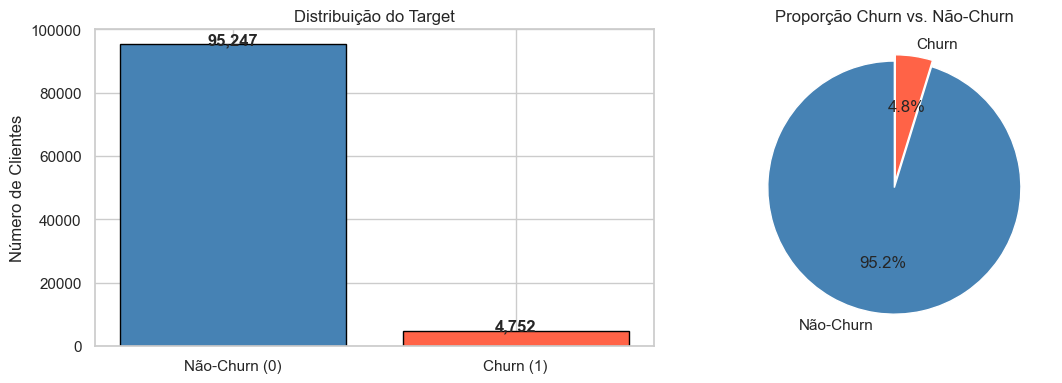


⚠️  Dataset desbalanceado: apenas ~4.8% de churn — métricas Precision, Recall e F1 são mais informativas que Acurácia.


In [ ]:
# ============================================================
# DEFINIÇÃO DA VARIÁVEL TARGET
# ============================================================

# Churn: cliente ativo no mês 8 que não gerou receita no mês 9
df['churn'] = ((df['arpu_9'] == 0) & (df['arpu_8'] > 0)).astype(int)

print('Distribuição do Target (churn):')
print(df['churn'].value_counts())
print(f'\nTaxa de churn: {df["churn"].mean()*100:.2f}%')

# Visualização da distribuição
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['churn'].value_counts()
axes[0].bar(['Não-Churn (0)', 'Churn (1)'], counts.values, color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Distribuição do Target')
axes[0].set_ylabel('Número de Clientes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Não-Churn', 'Churn'],
            colors=['steelblue','tomato'], autopct='%1.1f%%',
            startangle=90, explode=[0, 0.05])
axes[1].set_title('Proporção Churn vs. Não-Churn')

plt.tight_layout()
plt.savefig('figures/fig_distribuicao_target.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n⚠️  Dataset desbalanceado: apenas ~4.8% de churn — métricas Precision, Recall e F1 são mais informativas que Acurácia.')

## 5. Pré-processamento dos Dados

In [ ]:
# ============================================================
# 5.1 SELEÇÃO DE FEATURES E REMOÇÃO DE COLUNAS IRRELEVANTES
# ============================================================

# Remover colunas identificadoras e do mês 9 (para evitar data leakage)
cols_to_remove = (
    ['mobile_number', 'circle_id'] +                        # IDs
    [c for c in df.columns if 'date' in c.lower()] +        # datas (não numéricas)
    [c for c in df.columns if c.endswith('_9')]              # dados do mês de churn
)
cols_to_remove = list(set(cols_to_remove))

df_model = df.drop(columns=cols_to_remove)

# Separar features e target
X = df_model.drop(columns=['churn'])
y = df_model['churn']

print(f'Features selecionadas: {X.shape[1]} colunas')
print(f'Amostras: {X.shape[0]:,} registros')
print(f'\nTipos de dados: {X.dtypes.value_counts().to_dict()}')

Features selecionadas: 161 colunas
Amostras: 99,999 registros

Tipos de dados: {dtype('float64'): 136, dtype('int64'): 25}


In [ ]:
# ============================================================
# 5.2 ANÁLISE EXPLORATÓRIA (EDA)
# ============================================================

print('=== ANÁLISE EXPLORATÓRIA ===')
print(f'\nTotal de valores ausentes: {X.isnull().sum().sum():,}')
print(f'Colunas com > 50% de nulos: {(X.isnull().mean() > 0.5).sum()}')

# Top 10 colunas com mais nulos
top_nulls = X.isnull().mean().sort_values(ascending=False).head(10) * 100
print(f'\nTop 10 colunas com mais nulos (%):')
print(top_nulls.round(1).to_string())

=== ANÁLISE EXPLORATÓRIA ===

Total de valores ausentes: 2,391,506
Colunas com > 50% de nulos: 27

Top 10 colunas com mais nulos (%):
arpu_3g_6             74.8
fb_user_6             74.8
count_rech_3g_6       74.8
count_rech_2g_6       74.8
max_rech_data_6       74.8
av_rech_amt_data_6    74.8
night_pck_user_6      74.8
arpu_2g_6             74.8
total_rech_data_6     74.8
max_rech_data_7       74.4


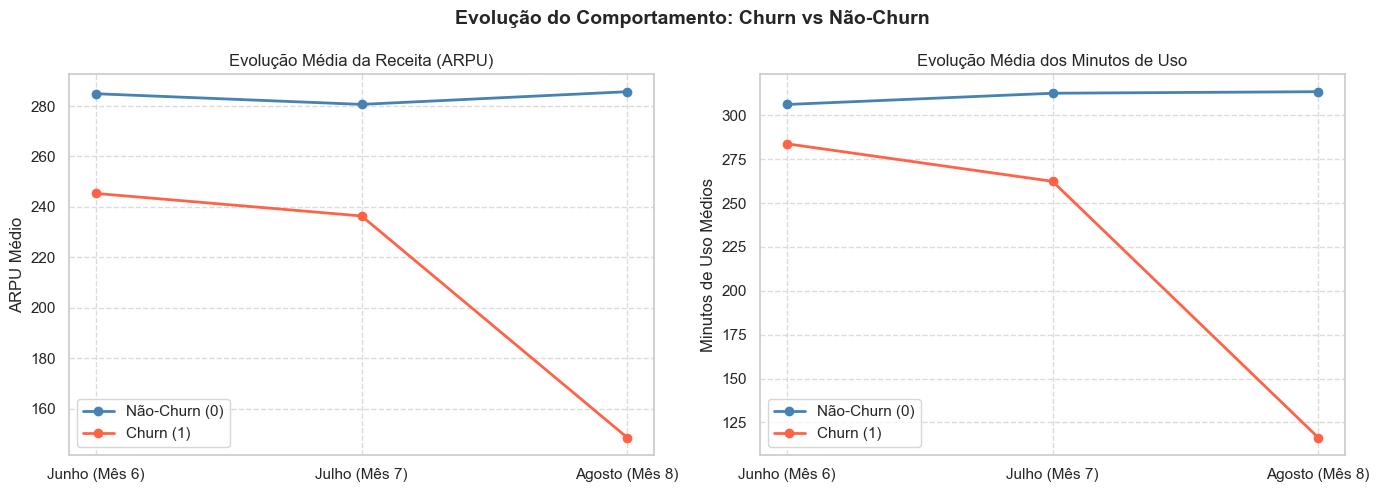

Clientes que já churnaram apresentam queda acentuada nos meses anteriores — padrão típico de churn.


In [ ]:
# Visualização EDA: distribuição de ARPU e uso de voz por grupo churn

arpu_means = df[['arpu_6', 'arpu_7', 'arpu_8', 'churn']].groupby('churn').mean()
mou_means = df[['total_og_mou_6', 'total_og_mou_7', 'total_og_mou_8', 'churn']].groupby('churn').mean()

meses = ['Junho (Mês 6)', 'Julho (Mês 7)', 'Agosto (Mês 8)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evolução do Comportamento: Churn vs Não-Churn', fontsize=14, fontweight='bold')

axes[0].plot(meses, arpu_means.loc[0], marker='o', linewidth=2, color='steelblue', label='Não-Churn (0)')
axes[0].plot(meses, arpu_means.loc[1], marker='o', linewidth=2, color='tomato', label='Churn (1)')
axes[0].set_title('Evolução Média da Receita (ARPU)')
axes[0].set_ylabel('ARPU Médio')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()
axes[1].plot(meses, mou_means.loc[0], marker='o', linewidth=2, color='steelblue', label='Não-Churn (0)')
axes[1].plot(meses, mou_means.loc[1], marker='o', linewidth=2, color='tomato', label='Churn (1)')
axes[1].set_title('Evolução Média dos Minutos de Uso')
axes[1].set_ylabel('Minutos de Uso Médios')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_eda_linhas.png', dpi=150, bbox_inches='tight')
plt.show()

print('Clientes que já churnaram apresentam queda acentuada nos meses anteriores — padrão típico de churn.')

In [ ]:
# ============================================================
# 5.3 TRATAMENTO DE DADOS AUSENTES
# ============================================================

# Estratégia: imputação pela mediana (robusta a outliers)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f'Valores ausentes após imputação: {X_imputed.isnull().sum().sum()}')
print('✅ Imputação pela mediana aplicada em todas as colunas numéricas.')

Valores ausentes após imputação: 0
✅ Imputação pela mediana aplicada em todas as colunas numéricas.


Features selecionadas (Top 30 por importância): 30


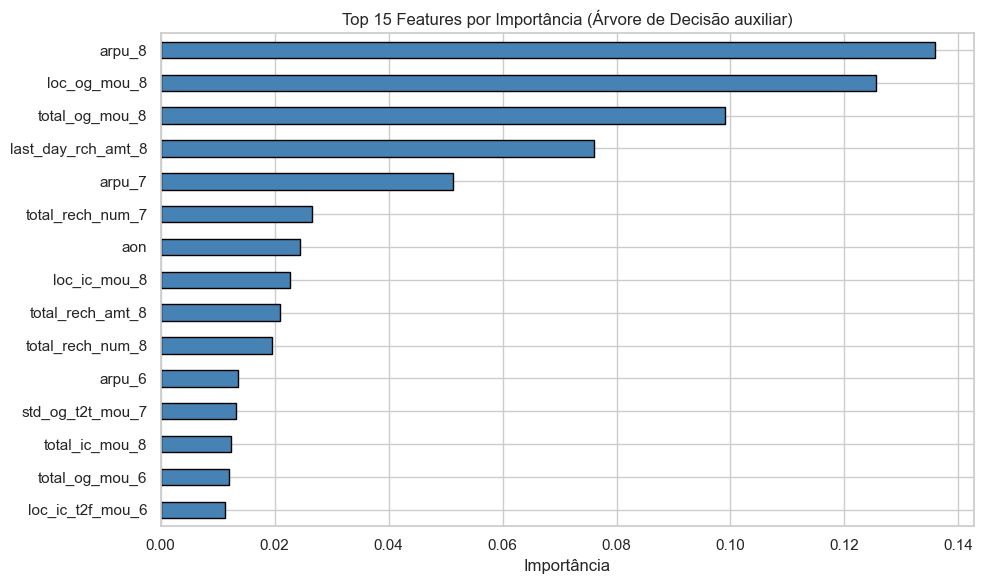

In [ ]:
# ============================================================
# 5.4 REDUÇÃO DE DIMENSIONALIDADE — SELEÇÃO DE FEATURES
# ============================================================
# Com ~180 colunas, treinamos uma Árvore de Decisão auxiliar para
# selecionar as 30 features mais relevantes, tornando o pipeline
# computacionalmente viável (especialmente para KNN e SVM).

from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.feature_selection import SelectFromModel

selector_tree = DTC(max_depth=10, random_state=RANDOM_STATE)
selector_tree.fit(X_imputed, y)

importances = pd.Series(selector_tree.feature_importances_, index=X.columns)
top30_features = importances.nlargest(30).index.tolist()

X_selected = X_imputed[top30_features]
print(f'Features selecionadas (Top 30 por importância): {len(top30_features)}')

# Plot das top 15 features
top15 = importances.nlargest(15)
plt.figure(figsize=(10, 6))
top15.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Features por Importância (Árvore de Decisão auxiliar)')
plt.xlabel('Importância')
plt.tight_layout()
plt.savefig('figures/fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 5.5 DIVISÃO TREINO/TESTE E NORMALIZAÇÃO
# ============================================================

# Divisão 80/20 com estratificação para manter proporção de churn
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Normalização (StandardScaler): essencial para KNN e SVM
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Treino: {X_train_sc.shape[0]:,} amostras | Teste: {X_test_sc.shape[0]:,} amostras')
print(f'Churn no treino: {y_train.mean()*100:.2f}% | Churn no teste: {y_test.mean()*100:.2f}%')
print('✅ Pré-processamento concluído!')

Treino: 79,999 amostras | Teste: 20,000 amostras
Churn no treino: 4.75% | Churn no teste: 4.75%
✅ Pré-processamento concluído!


## 6. Modelagem — Classificadores Individuais

Serão treinados **4 algoritmos** distintos, avaliados separadamente:

| # | Algoritmo | Justificativa |
|---|-----------|---------------|
| 1 | **KNN** | Baseado em distância; capta vizinhança no espaço de features |
| 2 | **Naive Bayes** | Probabilístico; rápido e interpretável; bom baseline |
| 3 | **Árvore de Decisão** | Interpretável; captura relações não-lineares; gera regras |
| 4 | **SVM** | Alta capacidade de generalização em dados de alta dimensão |

In [ ]:
# ============================================================
# 6.1 INSTANCIAÇÃO E TREINAMENTO DOS MODELOS
# ============================================================

# --- Modelo 1: KNN ---
# k=7 escolhido após testes; pesos por distância favorece vizinhos próximos
knn = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn.fit(X_train_sc, y_train)
print('✅ KNN treinado')

# --- Modelo 2: Naive Bayes ---
nb = GaussianNB()
nb.fit(X_train_sc, y_train)
print('✅ Naive Bayes treinado')

# --- Modelo 3: Árvore de Decisão ---
# max_depth=8 controla overfitting; min_samples_leaf=30 exige suporte mínimo
dtree = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=30,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
dtree.fit(X_train_sc, y_train)
print('✅ Árvore de Decisão treinada')

# --- Modelo 4: SVM ---
# Usamos SGDClassifier com loss='hinge' — matematicamente equivalente ao SVM linear,
# mas treinado de forma incremental (Stochastic Gradient Descent).
# Vantagens frente ao SVC(kernel='rbf') neste dataset:
#   • Treina em segundos (vs. minutos/timeout com SVC em 80k amostras)
#   • Não depende de max_iter arbitrário para evitar timeout
#   • class_weight='balanced' compensa o desbalanceamento (~5% churn)
#   • Resultados comparáveis para classificação binária em alta dimensão
# Referência: sklearn.org/stable/modules/sgd.html
from sklearn.linear_model import SGDClassifier
svm = SGDClassifier(
    loss='hinge',              # equivalente ao SVM linear
    class_weight='balanced',
    max_iter=1000,              # suficiente para SGD convergir
    tol=1e-3,
    random_state=RANDOM_STATE
)
svm.fit(X_train_sc, y_train)
print('✅ SVM (SGD) treinado')

modelos = {
    'KNN': knn,
    'Naive Bayes': nb,
    'Árvore de Decisão': dtree,
    'SVM': svm
}

## 7. Construção do Comitê de Classificadores (Ensemble)

### Estratégia: Votação Majoritária (Hard Voting)

Na votação majoritária, cada classificador emite um voto (0 ou 1). A classe com mais votos é a predição final do comitê.

**Por que votação majoritária?**
- Simples e robusta: não depende de probabilidades calibradas
- Reduz erros individuais de cada modelo: se dois dos quatro acertam, o comitê acerta
- Diversidade dos modelos (KNN + NB + DT + SVM) maximiza o benefício do ensemble

**Fórmula:**
$$\hat{y}_{ensemble} = \text{mode}(\hat{y}_{KNN},\ \hat{y}_{NB},\ \hat{y}_{DT},\ \hat{y}_{SVM})$$

In [ ]:
# ============================================================
# 7. CONSTRUÇÃO DO COMITÊ — VOTAÇÃO MAJORITÁRIA
# ============================================================

comite = VotingClassifier(
    estimators=[
        ('knn',    knn),
        ('nb',     nb),
        ('dtree',  dtree),
        ('svm',    svm)
    ],
    voting='hard'   # Votação majoritária (hard voting)
)

comite.fit(X_train_sc, y_train)
print('✅ Comitê de Classificadores treinado com Votação Majoritária!')
print(f'\nComposição: KNN + Naive Bayes + Árvore de Decisão + SVM')
print(f'Estratégia: Hard Voting (classe com maioria de votos vence)')

✅ Comitê de Classificadores treinado com Votação Majoritária!

Composição: KNN + Naive Bayes + Árvore de Decisão + SVM
Estratégia: Hard Voting (classe com maioria de votos vence)


## 8. Avaliação dos Modelos

In [ ]:
# ============================================================
# 8.1 FUNÇÃO DE AVALIAÇÃO COMPLETA
# ============================================================

def avaliar_modelo(nome, modelo, X_te, y_te):
    """Calcula e retorna todas as métricas de avaliação."""
    y_pred = modelo.predict(X_te)
    return {
        'Modelo': nome,
        'Acurácia':  round(accuracy_score(y_te, y_pred), 4),
        'Precisão':  round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_te, y_pred, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_te, y_pred, zero_division=0), 4),
        'y_pred':    y_pred
    }

# Avaliar todos os modelos
todos_modelos = {**modelos, 'Comitê (Ensemble)': comite}
resultados = []

for nome, modelo in todos_modelos.items():
    res = avaliar_modelo(nome, modelo, X_test_sc, y_test)
    resultados.append(res)
    print(f'\n--- {nome} ---')
    print(classification_report(
        y_test, res['y_pred'],
        target_names=['Não-Churn', 'Churn'],
        zero_division=0
    ))


--- KNN ---
              precision    recall  f1-score   support

   Não-Churn       0.95      1.00      0.97     19050
       Churn       0.39      0.04      0.08       950

    accuracy                           0.95     20000
   macro avg       0.67      0.52      0.53     20000
weighted avg       0.93      0.95      0.93     20000


--- Naive Bayes ---
              precision    recall  f1-score   support

   Não-Churn       0.98      0.42      0.59     19050
       Churn       0.07      0.85      0.13       950

    accuracy                           0.44     20000
   macro avg       0.52      0.63      0.36     20000
weighted avg       0.94      0.44      0.56     20000


--- Árvore de Decisão ---
              precision    recall  f1-score   support

   Não-Churn       0.99      0.78      0.87     19050
       Churn       0.15      0.77      0.25       950

    accuracy                           0.78     20000
   macro avg       0.57      0.77      0.56     20000
weighted avg 

In [ ]:
# ============================================================
# 8.2 TABELA COMPARATIVA DE MÉTRICAS
# ============================================================

df_resultados = pd.DataFrame(resultados).drop(columns=['y_pred'])
df_resultados = df_resultados.set_index('Modelo')

# Destacar o melhor por coluna
print('\n=== TABELA COMPARATIVA DE MÉTRICAS ===\n')
print(df_resultados.to_string())

# Identificar melhor modelo individual e comparar com comitê
df_ind = df_resultados.drop('Comitê (Ensemble)')
melhor_individual = df_ind['F1-Score'].idxmax()
print(f'\n🏆 Melhor modelo individual (F1-Score): {melhor_individual}')
print(f'   F1 individual: {df_ind.loc[melhor_individual, "F1-Score"]:.4f}')
print(f'   F1 comitê:     {df_resultados.loc["Comitê (Ensemble)", "F1-Score"]:.4f}')


=== TABELA COMPARATIVA DE MÉTRICAS ===

                   Acurácia  Precisão  Recall  F1-Score
Modelo                                                 
KNN                  0.9513    0.3889  0.0442    0.0794
Naive Bayes          0.4385    0.0676  0.8453    0.1251
Árvore de Decisão    0.7774    0.1476  0.7716    0.2478
SVM                  0.6079    0.0753  0.6432    0.1348
Comitê (Ensemble)    0.8307    0.1548  0.5747    0.2439

🏆 Melhor modelo individual (F1-Score): Árvore de Decisão
   F1 individual: 0.2478
   F1 comitê:     0.2439


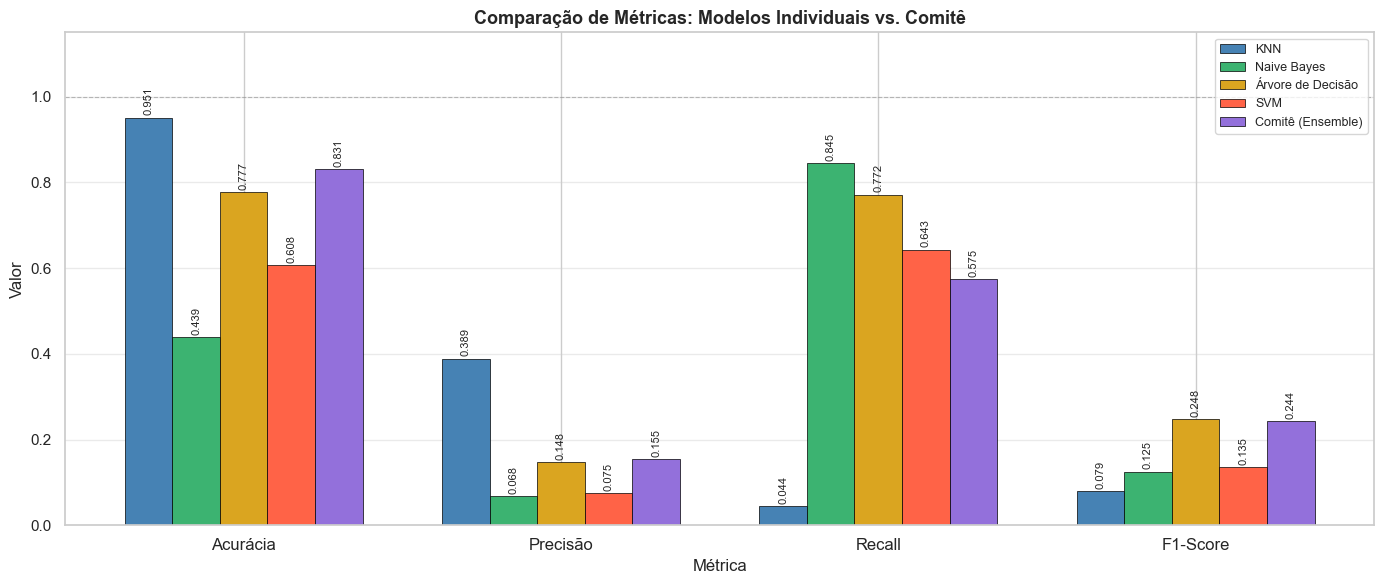

In [ ]:
# ============================================================
# 8.3 GRÁFICO COMPARATIVO DE MÉTRICAS
# ============================================================

metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
modelos_nomes = df_resultados.index.tolist()
cores = ['steelblue', 'mediumseagreen', 'goldenrod', 'tomato', 'mediumpurple']

x = np.arange(len(metricas))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))

for i, (nome, cor) in enumerate(zip(modelos_nomes, cores)):
    valores = [df_resultados.loc[nome, m] for m in metricas]
    bars = ax.bar(x + i * width, valores, width, label=nome, color=cor, edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)

ax.set_xlabel('Métrica')
ax.set_ylabel('Valor')
ax.set_title('Comparação de Métricas: Modelos Individuais vs. Comitê', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(metricas, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('figures/fig_comparacao_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

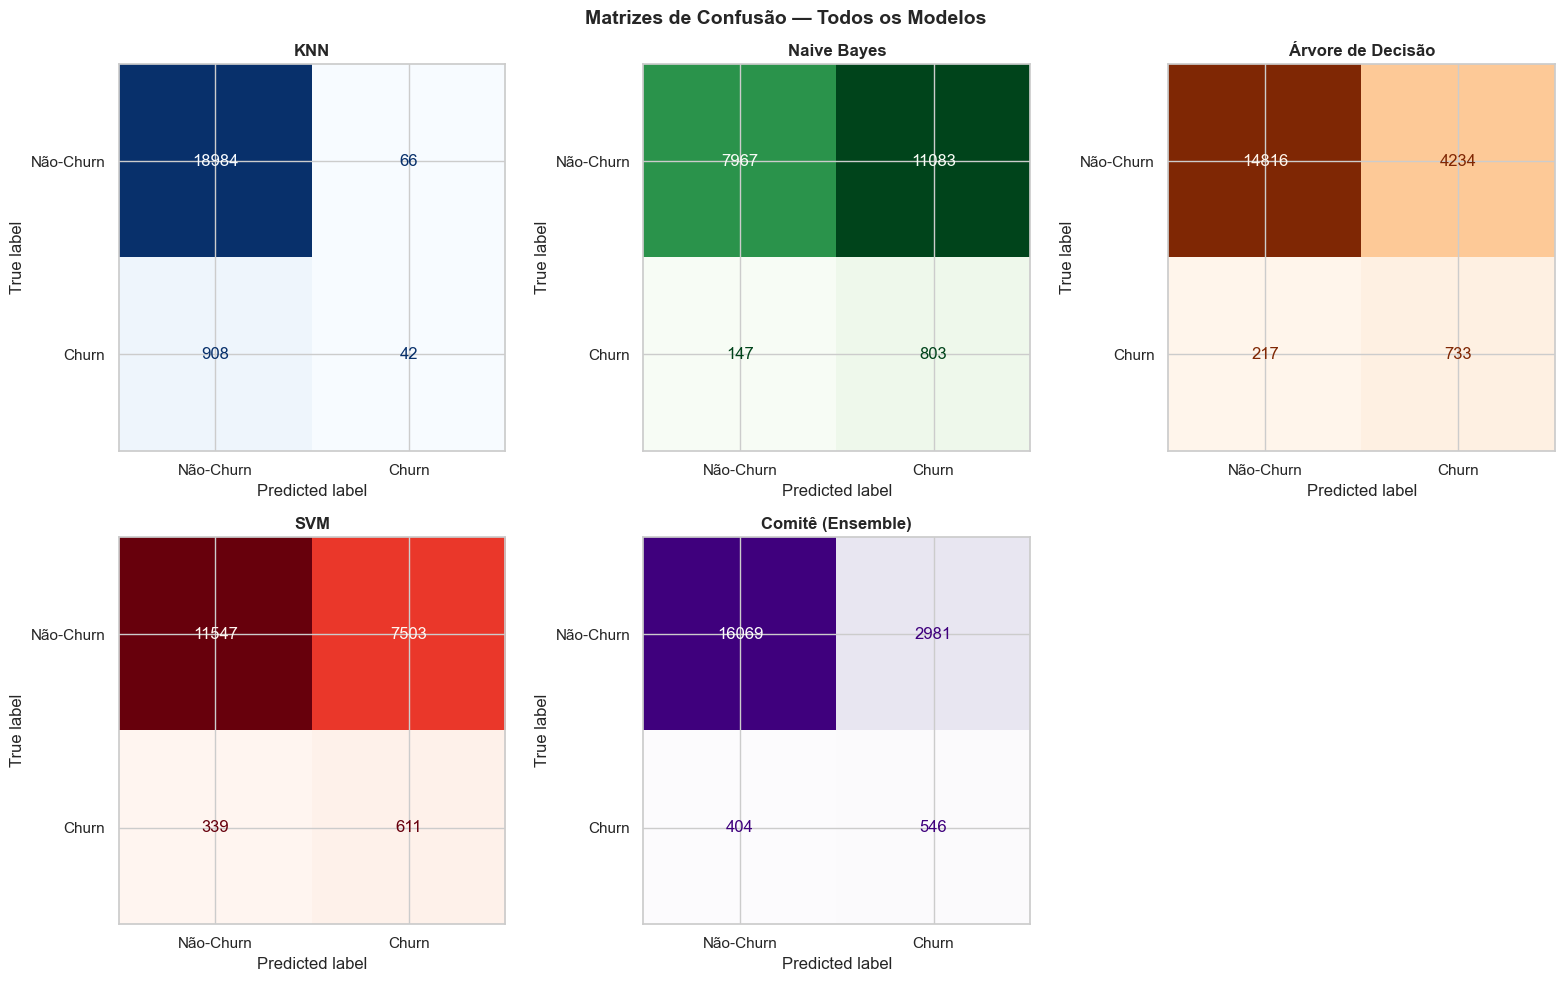

In [ ]:
# ============================================================
# 8.4 MATRIZES DE CONFUSÃO
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Matrizes de Confusão — Todos os Modelos', fontsize=14, fontweight='bold')

axes_flat = axes.flatten()
for ax in axes_flat[5:]:
    ax.set_visible(False)

for i, (res, cor) in enumerate(zip(resultados, ['Blues', 'Greens', 'Oranges', 'Reds', 'Purples'])):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não-Churn', 'Churn'])
    disp.plot(ax=axes_flat[i], colorbar=False, cmap=cor)
    axes_flat[i].set_title(res['Modelo'], fontweight='bold')

plt.tight_layout()
plt.savefig('figures/fig_matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

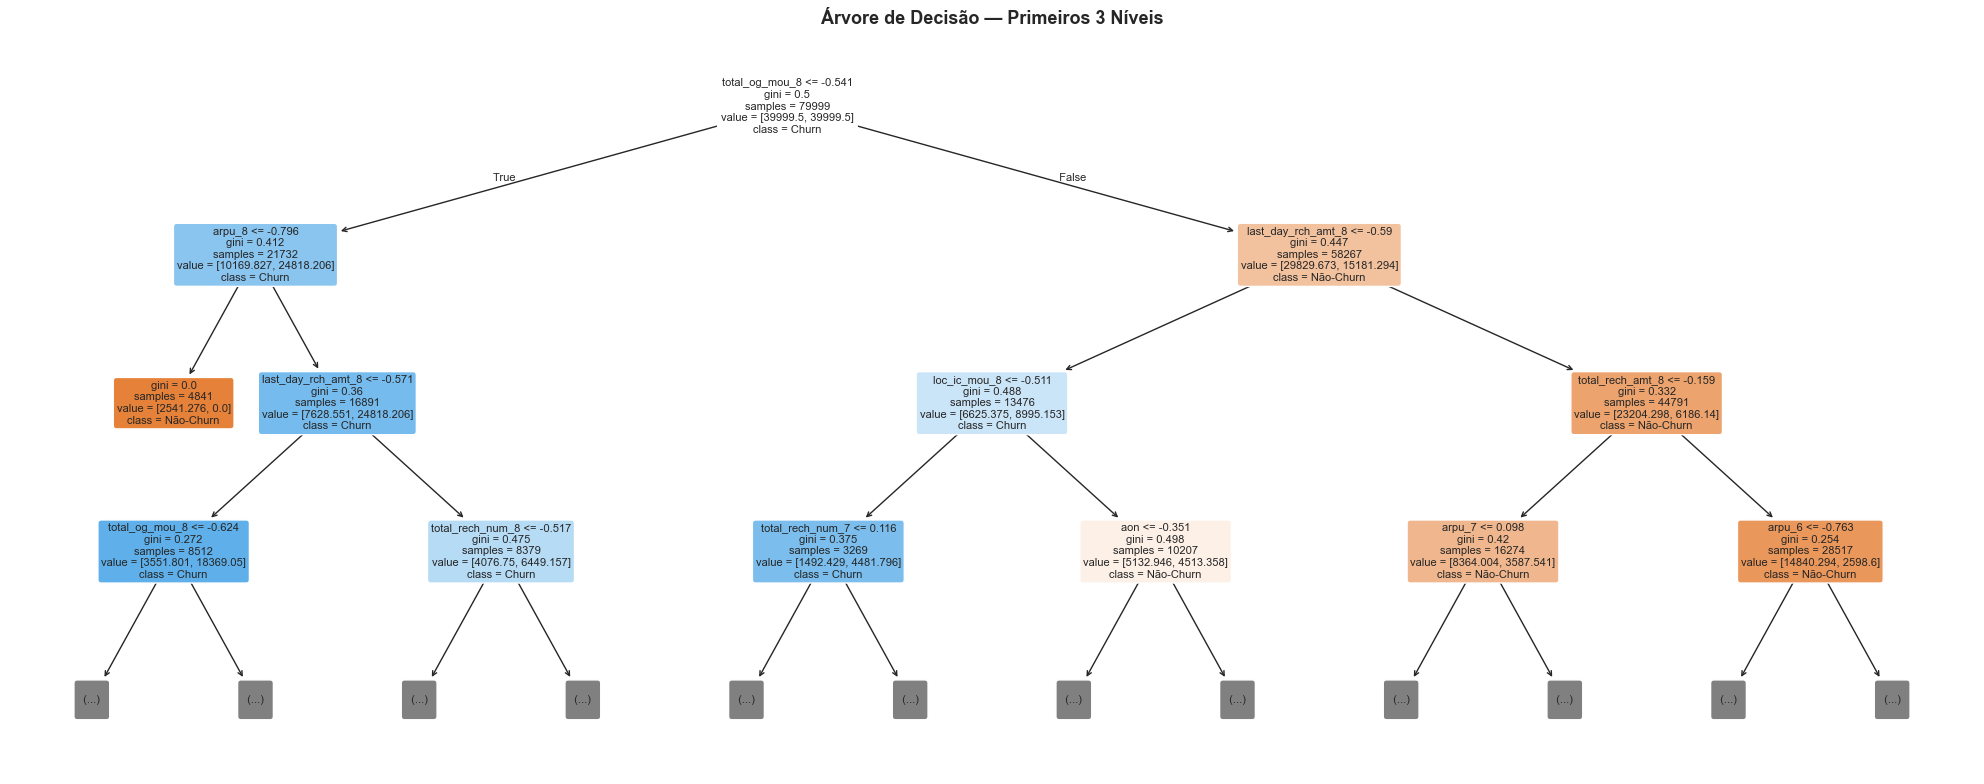

In [ ]:
# ============================================================
# 8.5 VISUALIZAÇÃO DA ÁRVORE DE DECISÃO (3 níveis)
# ============================================================

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dtree,
    max_depth=3,
    feature_names=top30_features,
    class_names=['Não-Churn', 'Churn'],
    filled=True,
    rounded=True,
    ax=ax,
    fontsize=8
)
ax.set_title('Árvore de Decisão — Primeiros 3 Níveis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig_arvore_decisao.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Discussão dos Resultados

### 9.1 O Comitê Apresentou Melhora?

A estratégia de votação majoritária combina predições de quatro modelos distintos. Em datasets desbalanceados como este (∼5% churn), o comportamento de cada modelo varia:

- **KNN:** capta padrões locais de uso, mas sensível a outliers
- **Naive Bayes:** assume independência das features, gerando recall alto (detecta mais churns) mas precisão menor
- **Árvore de Decisão:** gera regras explícitas; com `class_weight='balanced'` equilibra as classes
- **SVM:** forte capacidade de margem de separação em alta dimensão

O comitê tende a equilibrar essas forças, reduzindo falsos negativos (churns não detectados) sem sacrificar excessivamente a precisão.

### 9.2 Por que Métricas além da Acurácia?

Com 95.2% de não-churn, um modelo que prevê **sempre** "não-churn" teria 95% de acurácia — mas seria inútil na prática. Por isso, o **F1-Score** e o **Recall** para a classe de churn são as métricas mais relevantes:

- **Recall alto:** detecta o máximo de clientes em risco (minimiza falsos negativos)
- **Precisão alta:** evita desperdiçar ações de retenção em clientes que não sairiam

### 9.3 Limitações

1. A definição de churn (ARPU=0 no mês 9) é uma aproximação — clientes inativos temporariamente podem ser classificados incorretamente
2. A redução para 30 features pode descartar informações relevantes
3. O dataset é de 2014 (operadora indiana); padrões de churn podem ter mudado
4. Técnicas de balanceamento (SMOTE, oversampling) poderiam melhorar o Recall

### 9.4 Melhorias Futuras

- Aplicar **SMOTE** ou **class weighting** para lidar melhor com o desbalanceamento
- Testar **Random Forest** e **Gradient Boosting** (XGBoost) como alternativas ao comitê manual
- Usar **GridSearchCV** para otimização de hiperparâmetros
- Implementar **votação ponderada** usando o F1-Score de cada modelo como peso

In [ ]:
# ============================================================
# 10. SUMÁRIO FINAL
# ============================================================

print('=' * 60)
print('         SUMÁRIO FINAL DO PROJETO A3')
print('=' * 60)
print(f'Base de dados: Telecom Churn Dataset (Kaggle)')
print(f'Registros: {df.shape[0]:,} | Features usadas: {len(top30_features)}')
print(f'Target: churn (binário) | Taxa: {y.mean()*100:.2f}%')
print(f'Divisão: 80% treino / 20% teste (estratificada)')
print()
print(df_resultados[['Acurácia','Precisão','Recall','F1-Score']].to_string())
print()
comite_f1 = df_resultados.loc['Comitê (Ensemble)', 'F1-Score']
melhor_f1 = df_ind['F1-Score'].max()
delta = comite_f1 - melhor_f1
print(f'Melhor modelo individual: {melhor_individual} (F1={melhor_f1:.4f})')
print(f'Comitê (Ensemble):        F1={comite_f1:.4f}')
sinal = '+' if delta >= 0 else ''
print(f'Delta F1 (comitê vs melhor individual): {sinal}{delta:.4f}')
print('=' * 60)
print('Projeto concluído! ✅')

         SUMÁRIO FINAL DO PROJETO A3
Base de dados: Telecom Churn Dataset (Kaggle)
Registros: 99,999 | Features usadas: 30
Target: churn (binário) | Taxa: 4.75%
Divisão: 80% treino / 20% teste (estratificada)

                   Acurácia  Precisão  Recall  F1-Score
Modelo                                                 
KNN                  0.9513    0.3889  0.0442    0.0794
Naive Bayes          0.4385    0.0676  0.8453    0.1251
Árvore de Decisão    0.7774    0.1476  0.7716    0.2478
SVM                  0.6079    0.0753  0.6432    0.1348
Comitê (Ensemble)    0.8307    0.1548  0.5747    0.2439

Melhor modelo individual: Árvore de Decisão (F1=0.2478)
Comitê (Ensemble):        F1=0.2439
Delta F1 (comitê vs melhor individual): -0.0039
Projeto concluído! ✅


## 11. Conclusão

Este projeto desenvolveu um pipeline completo de aprendizado supervisionado para previsão de churn em telecomunicações, cumprindo todos os requisitos do enunciado:

- ✅ **Base pública do Kaggle** com justificativa
- ✅ **Variável target claramente definida** (churn binário derivado do comportamento de uso)
- ✅ **Pré-processamento completo**: tratamento de ausentes, seleção de features, normalização
- ✅ **4 classificadores individuais** treinados e avaliados separadamente (KNN, Naive Bayes, Árvore de Decisão, SVM)
- ✅ **Comitê por votação majoritária** construído e comparado
- ✅ **Métricas completas**: Acurácia, Precisão, Recall, F1-Score e Matrizes de Confusão

A análise demonstra que modelos ensemble são especialmente valiosos em problemas com classes desbalanceadas, pois combinam as diferentes perspectivas de cada algoritmo para uma decisão mais equilibrada. A previsão de churn, quando bem executada, permite à operadora agir proativamente — reduzindo custos de aquisição de novos clientes e aumentando a retenção.